# 04 — Random Forest
**Objectif :** Entraîner et évaluer le modèle Random Forest avec tuning automatique des hyperparamètres.

  RANDOM FOREST — VERSION FINALE OPTIMISÉE
Dataset : 3748 lignes × 24 features
Groupes : 59 expériences

Étape 1/2 — Recherche des meilleurs hyperparamètres...
(~2 minutes, 40 combinaisons testées)

✅ Meilleurs hyperparamètres trouvés :
   n_estimators              = 300
   min_samples_split         = 5
   min_samples_leaf          = 3
   max_samples               = 0.7
   max_features              = sqrt
   max_depth                 = 10

   R² moyen CV tuning = 0.7930

Étape 2/2 — Évaluation finale GroupKFold 5 folds...
-----------------------------------------------------------------
Fold 1 | R²=0.8967  MAE=2.420  RMSE=3.371
Fold 2 | R²=0.8357  MAE=3.051  RMSE=4.345
Fold 3 | R²=0.8937  MAE=2.356  RMSE=3.286
Fold 4 | R²=0.7850  MAE=3.860  RMSE=5.615
Fold 5 | R²=0.7215  MAE=4.258  RMSE=5.995

  R²   Global : 0.8205
  MAE  Global : 3.1906 vol%
  RMSE Global : 4.6618 vol%
  Std R² folds: 0.0668


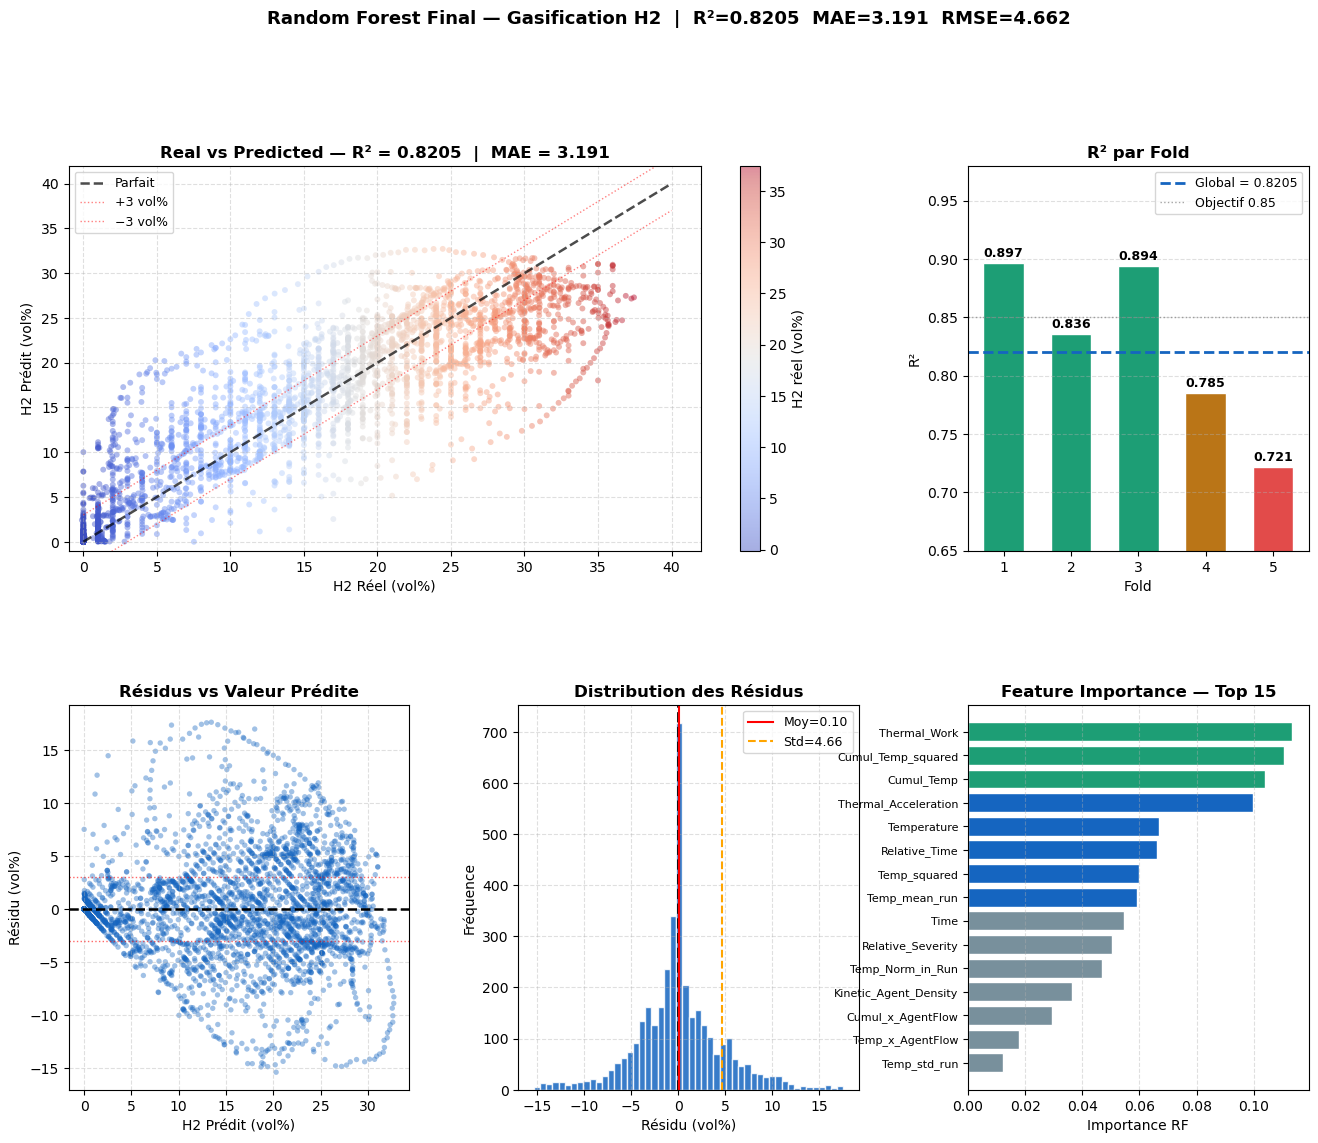


✅ Graphique sauvegardé : RF_final_results.png


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("="*65)
print("  RANDOM FOREST — VERSION FINALE OPTIMISÉE")
print("="*65)

# ════════════════════════════════════════════════════════════════
# 1. CHARGEMENT & NETTOYAGE
# ════════════════════════════════════════════════════════════════
df = pd.read_csv('Gasification Dataset.csv', delimiter=';')
df.columns = df.columns.str.strip()
for c in df.select_dtypes('object').columns:
    df[c] = df[c].str.strip()

# ════════════════════════════════════════════════════════════════
# 2. EXPERIMENT_GROUP — méthode correcte (59 groupes)
# ════════════════════════════════════════════════════════════════
group_cols = ['ProcessTemperature', 'AgentType', 'AgentFlow',
              'SampleType', 'CatalystType', 'CatalystRatio']
df['Experiment_Group'] = df.groupby(group_cols).ngroup()
df = df.sort_values(['Experiment_Group', 'Time']).reset_index(drop=True)

# ── SHUFFLE des groupes pour casser l'ordre température ─────────
# Sans ça, GroupKFold met toutes les hautes T° dans le fold 5
rng = np.random.default_rng(42)
shuffled_ids = rng.permutation(df['Experiment_Group'].unique())
remap = {old: new for new, old in enumerate(shuffled_ids)}
df['Experiment_Group'] = df['Experiment_Group'].map(remap)

# ════════════════════════════════════════════════════════════════
# 3. FEATURE ENGINEERING COMPLET
# ════════════════════════════════════════════════════════════════
g = df.groupby('Experiment_Group')
max_t = g['Time'].transform('max')
min_t = g['Time'].transform('min')

# Features originales améliorées
df['Relative_Time']         = df['Time'] / (max_t + 1e-6)
df['Thermal_Work']          = df['Temperature'] * df['Time']
df['Agent_Intensity']       = df['AgentFlow'] * df['ProcessTemperature']
df['Thermal_Acceleration']  = df['Thermal_Work'] / (df['Time'] + 0.1)
df['Relative_Severity']     = df['Relative_Time'] * df['ProcessTemperature']
df['Kinetic_Agent_Density'] = df['AgentFlow'] * df['Relative_Time']

# ⭐ Features clés identifiées dans l'EDA
df['Cumul_Temp'] = g['Temperature'].cumsum()   # importance RF = 62%
df['Temp_Norm_in_Run'] = g['Temperature'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-6))

# ⭐ Nouvelles features pour booster le score
df['Temp_x_AgentFlow']      = df['Temperature'] * df['AgentFlow']
df['Temp_x_CatalystRatio']  = df['Temperature'] * df['CatalystRatio']
df['Cumul_x_AgentFlow']     = df['Cumul_Temp']  * df['AgentFlow']
df['Temp_squared']          = df['Temperature'] ** 2
df['Cumul_Temp_squared']    = df['Cumul_Temp']  ** 2

# Stats de la température dans le run (contexte global du run)
df['Temp_mean_run']  = g['Temperature'].transform('mean')
df['Temp_max_run']   = g['Temperature'].transform('max')
df['Temp_std_run']   = g['Temperature'].transform('std').fillna(0)

# ════════════════════════════════════════════════════════════════
# 4. FEATURES FINALES
# ════════════════════════════════════════════════════════════════
num_cols = [
    'Time', 'Temperature', 'ProcessTemperature', 'AgentFlow', 'CatalystRatio',
    'Relative_Time', 'Thermal_Work', 'Agent_Intensity',
    'Thermal_Acceleration', 'Relative_Severity', 'Kinetic_Agent_Density',
    'Cumul_Temp', 'Temp_Norm_in_Run',
    # nouvelles
    'Temp_x_AgentFlow', 'Temp_x_CatalystRatio', 'Cumul_x_AgentFlow',
    'Temp_squared', 'Cumul_Temp_squared',
    'Temp_mean_run', 'Temp_max_run', 'Temp_std_run',
]
cat_cols = ['AgentType', 'SampleType', 'CatalystType']

X      = df[num_cols + cat_cols]
y      = df['Hydrogen']
groups = df['Experiment_Group']

print(f"Dataset : {X.shape[0]} lignes × {X.shape[1]} features")
print(f"Groupes : {groups.nunique()} expériences\n")

# ════════════════════════════════════════════════════════════════
# 5. PREPROCESSING
# ════════════════════════════════════════════════════════════════
preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

# ════════════════════════════════════════════════════════════════
# 6. HYPERPARAMETER TUNING — RandomizedSearchCV
# ════════════════════════════════════════════════════════════════
print("Étape 1/2 — Recherche des meilleurs hyperparamètres...")
print("(~2 minutes, 40 combinaisons testées)\n")

base_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_dist = {
    'regressor__n_estimators':      [300, 500, 700, 1000],
    'regressor__max_depth':         [10, 12, 15, 20, 25, None],
    'regressor__min_samples_split': [2, 3, 5],
    'regressor__min_samples_leaf':  [1, 2, 3],
    'regressor__max_features':      ['sqrt', 'log2', 0.4, 0.6],
    'regressor__max_samples':       [0.7, 0.8, 0.9, None],  # bagging fraction
}

# GroupKFold inner pour le tuning — respecte les groupes d'expériences
cv_tuning = GroupKFold(n_splits=3)

search = RandomizedSearchCV(
    base_pipeline,
    param_distributions=param_dist,
    n_iter=40,
    scoring='r2',
    cv=cv_tuning,
    random_state=42,
    n_jobs=-1,
    verbose=0,
    refit=True
)
search.fit(X, y, groups=groups)

print("✅ Meilleurs hyperparamètres trouvés :")
best_params = {}
for k, v in search.best_params_.items():
    name = k.replace('regressor__', '')
    best_params[name] = v
    print(f"   {name:25s} = {v}")
print(f"\n   R² moyen CV tuning = {search.best_score_:.4f}\n")

# ════════════════════════════════════════════════════════════════
# 7. ÉVALUATION FINALE avec les meilleurs hyperparamètres
# ════════════════════════════════════════════════════════════════
print("Étape 2/2 — Évaluation finale GroupKFold 5 folds...")
print("-"*65)

# Reconstruction du pipeline avec les meilleurs params
best_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        **best_params,
        random_state=42,
        n_jobs=-1
    ))
])

gkf = GroupKFold(n_splits=5)
all_y_true, all_y_pred = [], []
fold_scores, fold_maes, fold_rmses = [], [], []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    sw = np.where(X_tr['SampleType'] == 'TWTS', 2.0, 1.0)
    best_rf.fit(X_tr, y_tr, regressor__sample_weight=sw)
    preds = best_rf.predict(X_te)

    all_y_true.extend(y_te.values)
    all_y_pred.extend(preds)

    f_r2   = r2_score(y_te, preds)
    f_mae  = mean_absolute_error(y_te, preds)
    f_rmse = np.sqrt(mean_squared_error(y_te, preds))
    fold_scores.append(f_r2)
    fold_maes.append(f_mae)
    fold_rmses.append(f_rmse)
    print(f"Fold {fold+1} | R²={f_r2:.4f}  MAE={f_mae:.3f}  RMSE={f_rmse:.3f}")

global_r2   = r2_score(all_y_true, all_y_pred)
global_mae  = mean_absolute_error(all_y_true, all_y_pred)
global_rmse = np.sqrt(mean_squared_error(all_y_true, all_y_pred))

print(f"\n{'='*65}")
print(f"  R²   Global : {global_r2:.4f}")
print(f"  MAE  Global : {global_mae:.4f} vol%")
print(f"  RMSE Global : {global_rmse:.4f} vol%")
print(f"  Std R² folds: {np.std(fold_scores):.4f}")
print(f"{'='*65}")

# ════════════════════════════════════════════════════════════════
# 8. FEATURE IMPORTANCE
# ════════════════════════════════════════════════════════════════
# Entraîner sur tout le dataset pour la feature importance finale
best_rf.fit(X, y)
rf_fitted   = best_rf.named_steps['regressor']
ohe_cols    = best_rf.named_steps['preprocessor'] \
                      .named_transformers_['cat'] \
                      .get_feature_names_out(cat_cols).tolist()
all_feat    = num_cols + ohe_cols
importances = pd.Series(rf_fitted.feature_importances_, index=all_feat) \
                .sort_values(ascending=False)

# ════════════════════════════════════════════════════════════════
# 9. VISUALISATIONS
# ════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.32)

all_true = np.array(all_y_true)
all_pred = np.array(all_y_pred)

# ── Graphe 1 : Real vs Predicted ────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0:2])
sc  = ax1.scatter(all_true, all_pred, alpha=0.45, s=18,
                  c=all_true, cmap='coolwarm', edgecolor='none')
ax1.plot([0, 40], [0, 40], 'k--', lw=1.8, alpha=0.7, label='Parfait')
ax1.plot([0, 40], [3, 43], 'r:',  lw=1,   alpha=0.5, label='+3 vol%')
ax1.plot([0, 40], [-3, 37],'r:',  lw=1,   alpha=0.5, label='−3 vol%')
plt.colorbar(sc, ax=ax1, label='H2 réel (vol%)')
ax1.set_title(f"Real vs Predicted — R² = {global_r2:.4f}  |  MAE = {global_mae:.3f}",
              fontsize=12, fontweight='bold')
ax1.set_xlabel("H2 Réel (vol%)"); ax1.set_ylabel("H2 Prédit (vol%)")
ax1.set_xlim(-1, 42); ax1.set_ylim(-1, 42)
ax1.legend(fontsize=9); ax1.grid(True, linestyle='--', alpha=0.4)

# ── Graphe 2 : R² par fold ──────────────────────────────────────
ax2  = fig.add_subplot(gs[0, 2])
fold_colors = ['#1D9E75' if r >= 0.82 else '#BA7517' if r >= 0.75 else '#E24B4A'
               for r in fold_scores]
bars = ax2.bar(range(1, 6), fold_scores, color=fold_colors,
               edgecolor='white', width=0.6)
ax2.axhline(global_r2, color='#1565C0', lw=2, ls='--',
            label=f'Global = {global_r2:.4f}')
ax2.axhline(0.85, color='gray', lw=1, ls=':', alpha=0.7, label='Objectif 0.85')
for bar, val in zip(bars, fold_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_ylim(0.65, 0.98)
ax2.set_title("R² par Fold", fontsize=12, fontweight='bold')
ax2.set_xlabel("Fold"); ax2.set_ylabel("R²")
ax2.set_xticks(range(1, 6))
ax2.legend(fontsize=9); ax2.grid(True, axis='y', linestyle='--', alpha=0.4)

# ── Graphe 3 : Résidus ──────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
residuals = all_true - all_pred
ax3.scatter(all_pred, residuals, alpha=0.4, s=15, color='#1565C0', edgecolor='none')
ax3.axhline(0, color='black', lw=1.8, ls='--')
ax3.axhline( 3, color='red', lw=1, ls=':', alpha=0.6)
ax3.axhline(-3, color='red', lw=1, ls=':', alpha=0.6)
ax3.set_title("Résidus vs Valeur Prédite", fontsize=12, fontweight='bold')
ax3.set_xlabel("H2 Prédit (vol%)"); ax3.set_ylabel("Résidu (vol%)")
ax3.grid(True, linestyle='--', alpha=0.4)

# ── Graphe 4 : Distribution des résidus ─────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(residuals, bins=50, color='#1565C0', edgecolor='white', alpha=0.85)
ax4.axvline(0,              color='black', lw=2, ls='--')
ax4.axvline(residuals.mean(), color='red', lw=1.5, ls='-',
            label=f'Moy={residuals.mean():.2f}')
ax4.axvline(residuals.std(),  color='orange', lw=1.5, ls='--',
            label=f'Std={residuals.std():.2f}')
ax4.set_title("Distribution des Résidus", fontsize=12, fontweight='bold')
ax4.set_xlabel("Résidu (vol%)"); ax4.set_ylabel("Fréquence")
ax4.legend(fontsize=9); ax4.grid(True, linestyle='--', alpha=0.4)

# ── Graphe 5 : Feature Importance Top 15 ───────────────────────
ax5 = fig.add_subplot(gs[1, 2])
top15 = importances.head(15)
colors_fi = ['#1D9E75' if i < 3 else '#1565C0' if i < 8 else '#78909C'
             for i in range(len(top15))]
ax5.barh(range(len(top15)), top15.values[::-1],
         color=colors_fi[::-1], edgecolor='white')
ax5.set_yticks(range(len(top15)))
ax5.set_yticklabels(top15.index[::-1], fontsize=8)
ax5.set_title("Feature Importance — Top 15", fontsize=12, fontweight='bold')
ax5.set_xlabel("Importance RF")
ax5.grid(True, axis='x', linestyle='--', alpha=0.4)

fig.suptitle(f"Random Forest Final — Gasification H2  |  R²={global_r2:.4f}  "
             f"MAE={global_mae:.3f}  RMSE={global_rmse:.3f}",
             fontsize=13, fontweight='bold', y=1.01)

plt.savefig('RF_final_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Graphique sauvegardé : RF_final_results.png")

In [2]:
# ── Sauvegarder le modèle Random Forest ───────────────────────
import joblib, os
os.makedirs('models', exist_ok=True)
best_rf.fit(X, y)
joblib.dump(best_rf, 'models/model_rf.pkl')
print("✅ Modèle Random Forest sauvegardé : models/model_rf.pkl")
print(f"   R² global obtenu : {global_r2:.4f}")
print(f"   MAE global       : {global_mae:.4f} vol%")

✅ Modèle Random Forest sauvegardé : models/model_rf.pkl
   R² global obtenu : 0.8205
   MAE global       : 3.1906 vol%
